In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import ast
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, clear_output

climate_df = pd.read_csv('climate_data.csv')
stock_price_df = pd.read_csv('daily_stock_price.csv')
firm_df = pd.read_csv('firm_hq_data.csv')

In [2]:
damage_col = "Total Damage, Adjusted ('000 US$)"
year_col = "Start Year"
disaster_type_col = "Disaster Type"

climate_clean_df = climate_df[[year_col, disaster_type_col, damage_col]].dropna(subset=[damage_col])
climate_agg_df = climate_clean_df.groupby([year_col, disaster_type_col])[damage_col].sum().reset_index()
climate_agg_df[damage_col] = climate_agg_df[damage_col] / 1000000

years_with_data = sorted(climate_agg_df[year_col].unique())
num_years = len(years_with_data)

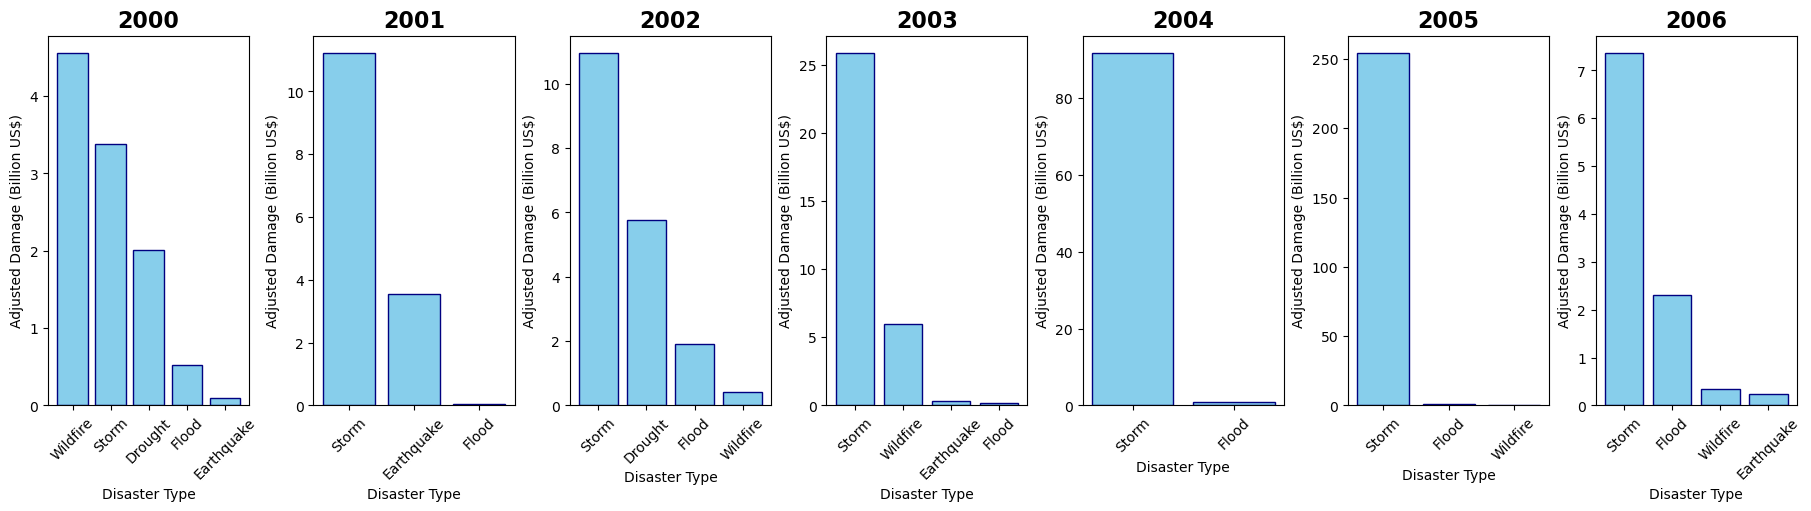

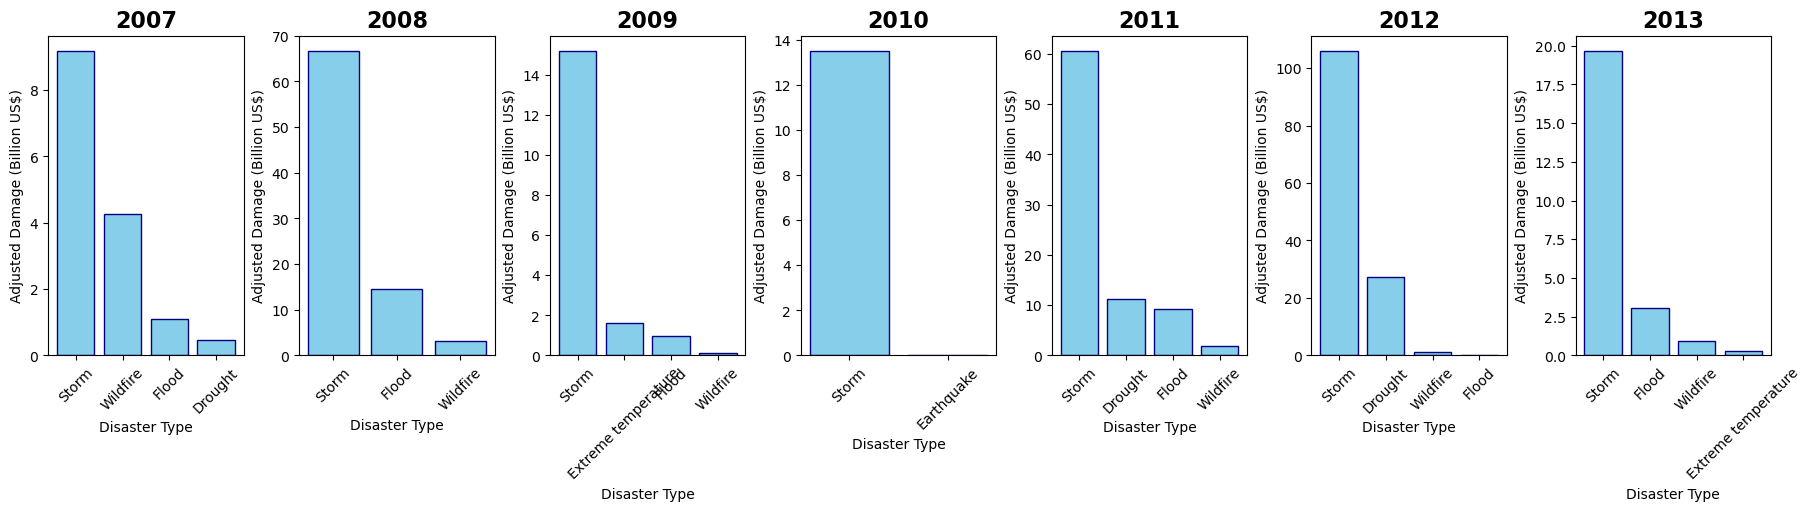

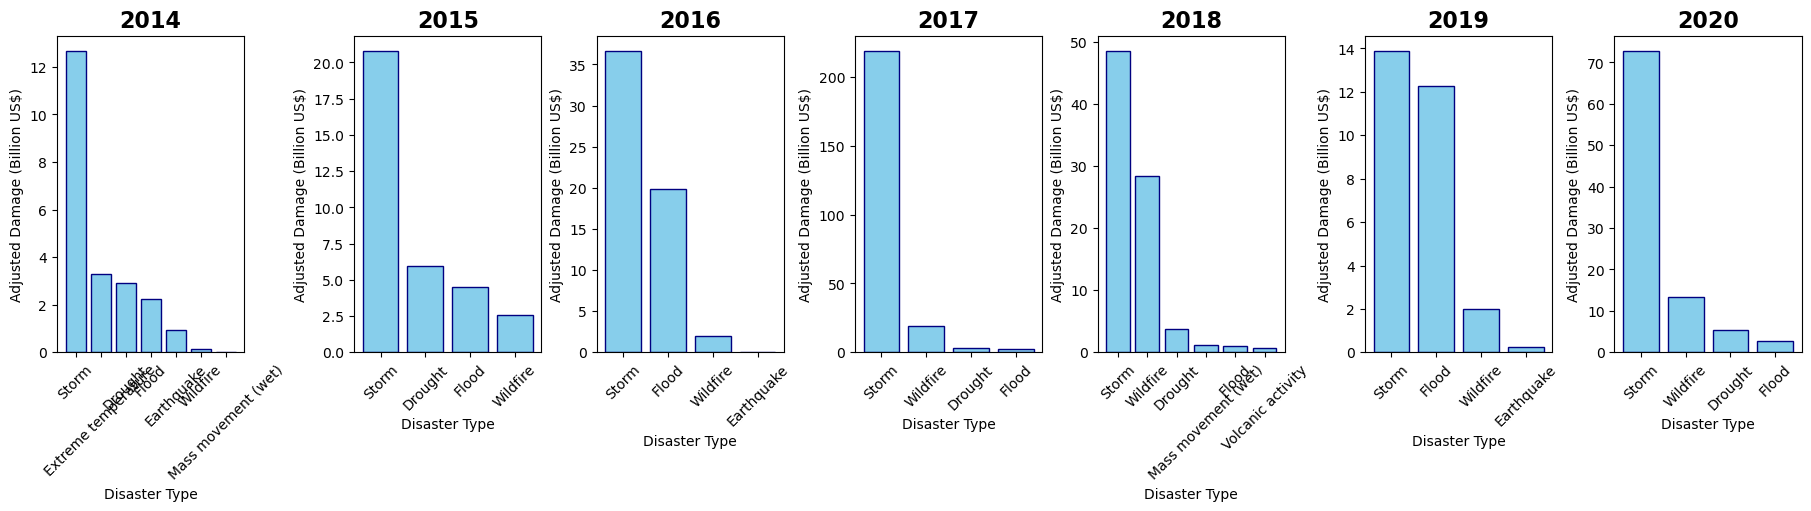

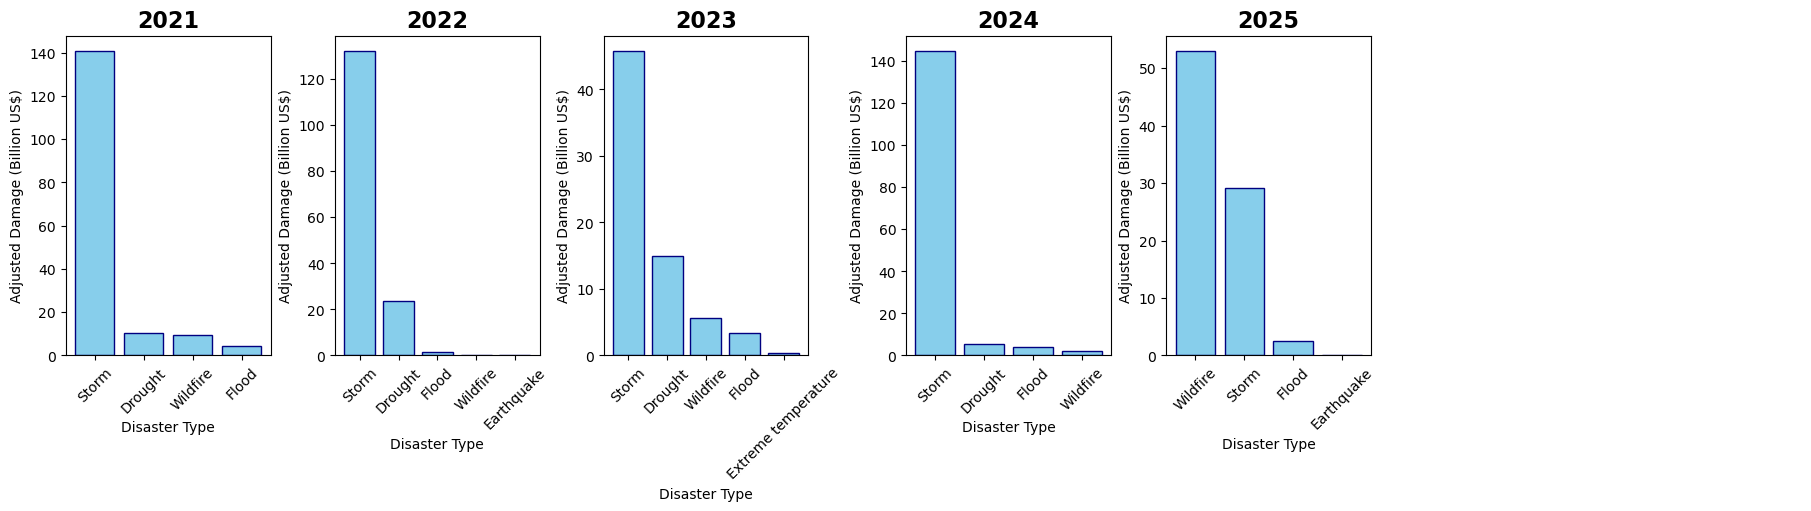

In [3]:
plots_per_fig = 7
num_figs = math.ceil(num_years / plots_per_fig)

for f in range(num_figs):
    start_index = f * plots_per_fig
    end_index = min((f + 1) * plots_per_fig, num_years)
    subset_years = years_with_data[start_index:end_index]

    n_cols = 7
    n_rows = math.ceil(len(subset_years) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize = (18, 5 * n_rows), constrained_layout = True)
    axes = axes.flatten()

    for i, year in enumerate(subset_years):
        year_data = climate_agg_df[climate_agg_df[year_col] == year].sort_values(by = damage_col, ascending=False)
        axes[i].bar(year_data[disaster_type_col], year_data[damage_col], color = 'skyblue', edgecolor = 'navy')
        axes[i].set_title(str(year), fontsize = 16, fontweight = 'bold')
        axes[i].set_xlabel("Disaster Type", fontsize = 10)
        axes[i].set_ylabel("Adjusted Damage (Billion US$)")
        axes[i].tick_params(axis = 'x', rotation = 45)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.show()
    

In [4]:
storm_df = climate_df[climate_df['Disaster Type'] == 'Storm'].copy()
storm_df[damage_col] = pd.to_numeric(storm_df[damage_col], errors = 'coerce')

top_storms = (
    storm_df.sort_values(['Start Year', damage_col], ascending = [True, False]).groupby('Start Year').head(3)
)

result = top_storms[['Start Year', 'Start Month', 'Start Day', damage_col]]
print(result)

     Start Year  Start Month  Start Day  Total Damage, Adjusted ('000 US$)
234        2000           12       16.0                           910827.0
637        2000            3       28.0                           819745.0
233        2000            1       22.0                           637579.0
391        2001            6        5.0                         10629520.0
133        2001            2       24.0                           442897.0
..          ...          ...        ...                                ...
82         2024           10        9.0                         38000000.0
75         2024            7        8.0                          7200000.0
18         2025            3       14.0                          9400000.0
3          2025            5       14.0                          5200000.0
8          2025            4        2.0                          4550000.0

[78 rows x 4 columns]


In [5]:
top_storms['Date'] = pd.to_datetime(dict(
    year = top_storms['Start Year'], 
    month = top_storms['Start Month'],
    day = top_storms['Start Day']
), errors = 'coerce')

stock_price_df['Date'] = pd.to_datetime(stock_price_df['Date'])

In [6]:
market_cols = stock_price_df.columns.drop('Date')
stock_price_df['Market_Mean'] = stock_price_df[market_cols].mean(axis = 1)
stock_price_df['Daily_Return'] = stock_price_df['Market_Mean'].pct_change() * 100

storm_dates = top_storms['Date'].unique()
stock_price_df['Is_Storm_Day'] = stock_price_df['Date'].isin(storm_dates)

avg_storm_return = stock_price_df[stock_price_df['Is_Storm_Day']]['Daily_Return'].mean()
avg_normal_return = stock_price_df[~stock_price_df['Is_Storm_Day']]['Daily_Return'].mean()

print(f"Average Market Return on Storm Days: {avg_storm_return: .4f}%")
print(f"Average Market Return on Non-Storm Days: {avg_normal_return: .4f}%")

Average Market Return on Storm Days:  0.1508%
Average Market Return on Non-Storm Days:  0.0373%


In [7]:
top_storms['Dropdown_Label'] = (
    top_storms['Start Year'].astype(int).astype(str) + " - " + 
    top_storms['Event Name'].fillna("Unnamed Storm")
)

storm_options = {row['Dropdown_Label']: index for index, row in top_storms.iterrows()}

dropdown = widgets.Dropdown(
    options = storm_options, 
    description = 'Select Storm:', 
    style = {'description_width': 'initial'}
)
output = widgets.Output()

def update_plot(change):
    storm_index = change['new']
    storm = top_storms.loc[storm_index]
    event_date = storm['Date']

    window = 15
    mask = (stock_price_df['Date'] >= event_date - pd.Timedelta(days = window)) & \
           (stock_price_df['Date'] <= event_date + pd.Timedelta(days = window))
    
    window_df = stock_price_df[mask]

    with output:
        clear_output(wait = True)
        if window_df.empty:
            print(f"No stock data available for {event_date.date()}.")
        else:
            plt.figure(figsize = (12, 5))
            plt.plot(window_df['Date'], window_df['Daily_Return'], 
                     marker = 'o', color = 'purple', linewidth = 2, label = 'Daily Return %')
            plt.axhline(0, color = 'black', linestyle = '-', linewidth = 1, alpha = 0.5)
            plt.axvline(x = event_date, color = 'red', linestyle = '--', label = 'Storm Start')
            plt.title(f"Market Fluctuation Around {storm['Dropdown_Label']}", fontsize = 14, fontweight = 'bold')
            plt.xlabel("Date")
            plt.ylabel("Average Daily Return (%)") # Label updated
            plt.grid(True, alpha = 0.3)
            plt.legend()
            plt.xticks(rotation = 45)
            plt.show()

dropdown.observe(update_plot, names='value')
display(dropdown)
display(output)

update_plot({'new': dropdown.value})

Dropdown(description='Select Storm:', options={'2000 - Unnamed Storm': 233, '2001 - Allison': 391, '2001 - Unn…

Output()

In [8]:
firm_df['HQ_Region'] = firm_df['Headquarters Location'].str.split(',').str[-1].str.strip()

local_dropdown = widgets.Dropdown(
    options = storm_options,
    description = 'Select Storm:',
    style = {'description_width': 'initial'}
)
local_output = widgets.Output()

def update_local_plot(change):
    storm_index = change['new']
    storm = top_storms.loc[storm_index]
    event_date = storm['Date']

    storm_loc = str(storm['Location']).lower()
    storm_country = str(storm['Country']).lower()

    local_tickers = []

    for _, firm in firm_df.iterrows():
        region = str(firm['HQ_Region']).lower()
        if (region in storm_loc or region == storm_country) and firm['Symbol'] in stock_price_df.columns:
            local_tickers.append(firm['Symbol'])

    window = 10
    mask = (stock_price_df['Date'] >= event_date - pd.Timedelta(days = window)) & \
           (stock_price_df['Date'] <= event_date + pd.Timedelta(days = window))
    window_df = stock_price_df[mask].copy()

    with local_output:
        clear_output(wait = True)
        if window_df.empty:
            print(f"No stock data available for {event_date.date()}.")
        else:
            plt.figure(figsize = (12, 6))
            plt.plot(window_df['Date'], window_df['Daily_Return'], marker = 'o', color = 'gray', alpha = 0.3, label = 'Overall Market Avg %')

            if local_tickers:
                local_return_series = window_df[local_tickers].pct_change(fill_method = None)
                local_mean_return = local_return_series.mean(axis = 1) * 100
                plt.plot(window_df['Date'], local_mean_return, marker = 's', color = 'darkorange', linewidth = 3, label = f'Local Firms Avg ({len(local_tickers)} matched)')

            plt.axhline(0, color = 'black', linestyle = '-', linewidth = 1, alpha = 0.5)
            plt.axvline(x = event_date, color = 'red', linestyle = '--', label = 'Storm Start')

            plt.title(f"Localized Impact: {storm['Dropdown_Label']}\nFirms Headquartered in {storm['Country']}", fontsize = 14, fontweight = 'bold')
            plt.xlabel("Date")
            plt.ylabel("Daily Fluctuation (%)")
            plt.grid(True, alpha = 0.2)
            plt.legend(loc='best')
            plt.xticks(rotation = 45)
            plt.show()

            if local_tickers:
                print(f"Firms Matched: {', '.join(local_tickers[:70])}{'...' if len(local_tickers) > 70 else ''}")
            else:
                print("No firms in the dataset matched this storm's headquarters location.")

local_dropdown.observe(update_local_plot, names = 'value')
display(local_dropdown)
display(local_output)

update_local_plot({'new': local_dropdown.value})

Dropdown(description='Select Storm:', options={'2000 - Unnamed Storm': 233, '2001 - Allison': 391, '2001 - Unn…

Output()